In [10]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from sympy import symbols
import utils_2Q_gate_zp as ut
from brokenaxes import brokenaxes
import qutip as qt
import scqubits as scq
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import plotly.graph_objects as go
import plotly.io as pio
import scipy as sp
from scipy.ndimage import gaussian_filter
from joblib import Parallel, delayed
from IPython.display import display, Math

In [11]:
truc1, truc_tot, charge_pick = 300, 1000, False
truc_tot_2 = 1000
num_cpus = 16
folder = f'../../data/3ncut_two_zeropi/truc1={truc1}_truc2={truc_tot}_pick={charge_pick}/'
hspace_full = pd.read_csv(folder+ 'hspace_full.txt').to_numpy().flatten().tolist()
eval_tot = 2*np.pi* pd.read_csv(folder+ 'eval_tot.txt').to_numpy().flatten()
n_theta0_dress = 2*np.pi* np.load(folder+'n_theta0_dress.npy')
n_theta1_dress = 2*np.pi* np.load(folder+'n_theta1_dress.npy')

eval_tot = eval_tot[:truc_tot_2]
hspace_full = hspace_full[:truc_tot_2]
n_theta0_dress = qt.Qobj(n_theta0_dress[np.ix_(np.arange(truc_tot_2), np.arange(truc_tot_2))])
n_theta1_dress = qt.Qobj(n_theta1_dress[np.ix_(np.arange(truc_tot_2), np.arange(truc_tot_2))])

In [12]:
ut.print_trans_freq('0-2','8-2', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('2-2','8-2', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)

ut.print_trans_freq('0-2','4-5', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('2-2','4-5', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)

ut.print_trans_freq('0-0','8-0', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('2-0','8-0', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)

ut.print_trans_freq('0-0','1-4', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)
ut.print_trans_freq('2-0','1-4', eval_tot, hspace=hspace_full, n_Theta=n_theta0_dress)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [13]:

ut.print_trans_freq('0-0','0-1', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('0-2','0-1', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)

ut.print_trans_freq('0-0','0-8', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)
ut.print_trans_freq('0-2','0-8', eval_tot, hspace=hspace_full, n_Theta=n_theta1_dress)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

#### Charge matrix element

In [85]:
logi_state = ['0-0', '0-2', '2-0', '2-2']
w_trans, n_trans, trans_int = ut.get_w_trans(eval_tot, hspace_full, n_theta0_dress, logi_state)
print('len(w_trans0)=', len(w_trans))

xlims = ((3.74, 4.09), (7.12, 7.545)) # 01 state
data = []
for i in range(len(w_trans)):
    for xlim in xlims:
        if xlim[0] < w_trans[i]/(2*np.pi) < xlim[1]:
            data.append({'w_trans': np.round(w_trans[i]/(2*np.pi), 3),
                       'state_i': trans_int[i][0],
                       'state_j': trans_int[i][1],
                       'n_theta0': n_trans[i],
                           })
df = pd.DataFrame(data)
df

len(w_trans0)= 131


,w_trans,state_i,state_j,n_theta0
0,3.756,2-0,8-0,0.043
1,3.780,2-2,8-2,0.058
2,3.836,2-0,1-4,0.047
3,3.970,2-2,4-5,0.030
4,4.062,2-0,4-1,0.018
5,4.080,2-2,0-18,0.001
6,7.148,2-0,9-1,0.010
7,7.176,2-2,9-5,0.012
8,7.225,0-0,8-0,0.027
9,7.249,0-2,8-2,0.037


Text(0.5, 0, 'Frequency (2$\\pi\\cdot$GHz)')

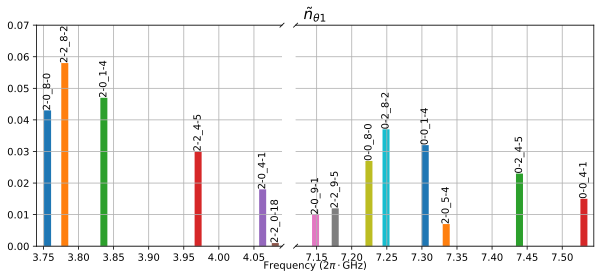

In [86]:
width = 0.8
y_shift = 0
fig = plt.figure(figsize=(10, 4))
bax = brokenaxes(xlims=xlims, wspace=0.05, d=0.004, despine=False, hspace=0.05)
for i in range(len(w_trans)):
    for xlim in xlims:
        if xlim[0] < w_trans[i]/(2*np.pi) < xlim[1]:
            txt_label = str(trans_int[i][0]) + '_' + str(trans_int[i][1])
            if trans_int[i] in [('0-2', '0-8'), ('2-0', '15-0')]:
                bax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.01, color='red', alpha=0.3)
                bax.text(w_trans[i]/(2*np.pi) +0.03, n_trans[i] , txt_label, ha="center",
                         va="bottom", rotation=90, fontsize=10)
            else:
                bax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.01, alpha=1)
                bax.text(w_trans[i]/(2*np.pi), n_trans[i] , txt_label, ha="center", va="bottom", rotation=90, fontsize=10)
bax.set_ylim(0, 0.07)
bax.grid()
bax.set_title(r'$\tilde{n}_{\theta 1}$', fontsize=15)
bax.set_xlabel(r'Frequency (2$\pi\cdot$GHz)')
# plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks

In [77]:
w_trans, n_trans, trans_int = ut.get_w_trans(eval_tot, hspace_full, n_theta1_dress, logi_state)
print('len(w_trans)=', len(w_trans))

xlims = ((3.701,3.91), (6.85, 7.54)) # 01 state
data = []
for i in range(len(w_trans)):
    for xlim in xlims:
        if xlim[0] < w_trans[i]/(2*np.pi) < xlim[1]:
            data.append({'w_trans': np.round(w_trans[i]/(2*np.pi), 3),
                       'state_i': trans_int[i][0],
                       'state_j': trans_int[i][1],
                       'n_theta1': n_trans[i],
                           })
df = pd.DataFrame(data)
df

len(w_trans)= 133


,w_trans,state_i,state_j,n_theta1
0,3.714,2-2,9-1,0.015
1,3.756,2-0,8-0,0.001
2,3.780,2-2,8-2,0.002
3,3.790,0-2,8-0,0.011
4,3.836,2-0,1-4,0.001
5,3.870,0-2,1-4,0.010
6,3.900,2-2,5-4,0.009
7,6.895,2-2,5-9,0.009
8,6.958,0-2,1-9,0.010
9,7.148,2-0,9-1,0.008


Text(0.5, 0, 'Frequency (2$\\pi\\cdot$GHz)')

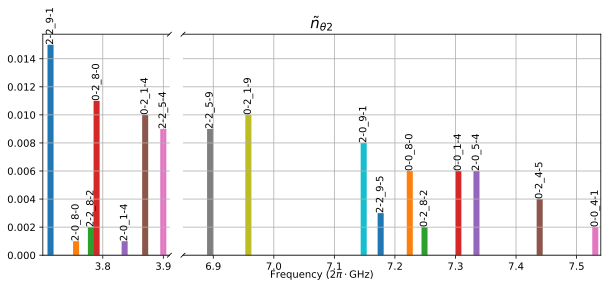

In [78]:
width = 0.8
y_shift = 0
fig = plt.figure(figsize=(10, 4))
bax = brokenaxes(xlims=xlims, wspace=0.05, d=0.004, despine=False, hspace=0.05)
for i in range(len(w_trans)):
    for xlim in xlims:
        if xlim[0] < w_trans[i]/(2*np.pi) < xlim[1]:
            txt_label = str(trans_int[i][0]) + '_' + str(trans_int[i][1])
            if trans_int[i] in [('0-2', '0-8'), ('0-0', '0-8')]:
                bax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.01, color='red', alpha=0.3)
                bax.text(w_trans[i]/(2*np.pi) +0.03, n_trans[i] , txt_label, ha="center",
                         va="bottom", rotation=90, fontsize=10)
            else:
                bax.bar(w_trans[i]/(2*np.pi), n_trans[i], width=0.01, alpha=1)
                bax.text(w_trans[i]/(2*np.pi), n_trans[i] , txt_label, ha="center", va="bottom", rotation=90, fontsize=10)
# bax.set_ylim(0, 0.105)
bax.grid()
bax.set_title(r'$\tilde{n}_{\theta 2}$', fontsize=15)
bax.set_xlabel(r'Frequency (2$\pi\cdot$GHz)')
# plt.xticks(np.arange(x_min, x_max, 2))  # Set custom x-axis ticks

In [9]:
=

SyntaxError: invalid syntax (1763773627.py, line 1)

#### Matrix element table

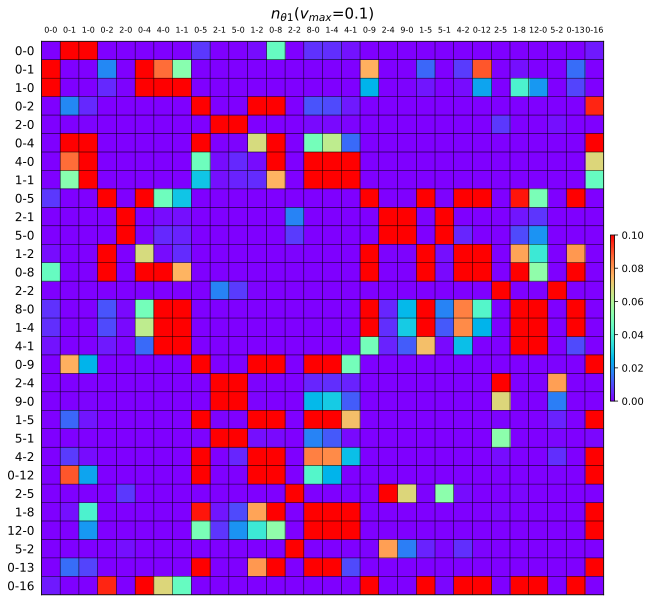

In [ ]:
vmax = 0.1
truc2 = 30
fig, ax = plt.subplots(figsize=(12,10))
font_size = 15
hspace_label = hspace_full[:truc2]
plt.imshow(np.abs(n_theta1_dress[:truc2,:truc2]/(2*np.pi)), vmax=vmax, aspect="auto",cmap='rainbow')
plt.title(r'$n_{\theta 1}$($v_{max}$='+f'{vmax})' , pad=8, fontsize=font_size)
ax.set_xticks(np.arange(0, truc2), hspace_label, fontsize=8)
ax.set_yticks(np.arange(0, truc2), hspace_label, fontsize=12)
ax.xaxis.tick_top()
ax.set_xticks(np.arange(-.5, truc2, 1), minor=True)
ax.set_yticks(np.arange(-.5, truc2, 1), minor=True)
ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)
ax.tick_params(which='both', left=False, top=False)
plt.colorbar(shrink=0.3, aspect=40, pad=0.01)
# plt.savefig('image/n_theta.png',dpi=150, bbox_inches='tight')